# Sesión 1 - Introducción a la Ciencia de datos y Machine Learning

> Alan Badillo Salas
> 
> Lunes 21, septiembre 2026


Ejemplo de una lista no ordenada:

- **Elemento 1** - Descripción
- **Elemento 2** - Otra descripción

Ejemplo de una lista ordenada

1. *A* - Descripción
2. *B* - Otra descripción

Ejemplo de una ecuación de *MathTex*

Dentro de una línea la $\sqrt{x}$, o más completo

$$
y = \beta_0 + \beta_1 \cdot x_1 + \beta_2 \cdot x_2 + \ldots + \beta_k \cdot x_k 
$$

A       | $C_1$ | $C_2$ | B
------: | :---- | :---: | ----------
Ana     | 34    | M     | 21/09/2026
Beto    | 32    | H     | 20/09/2026
Carla   | 28    | M     | 25/09/2026
Eduardo | 45    | H     | 18/09/2026
Fabian  | 60    | H     | 22/09/2026
Gus     | 16    | H     | 21/09/2026

## Paso 0 - Instalación e importación de librerías

In [2]:
# Comentario - Ejecutar un comando del sistema operativo
# SINTAXIS: ! <comando>

! dir

 El volumen de la unidad C es Windows
 El n�mero de serie del volumen es: 7876-B30D

 Directorio de c:\Users\drago\OneDrive\Desktop\banxico

21/09/2026  14:46    <DIR>          .
21/09/2026  14:30    <DIR>          ..
21/09/2026  14:31    <DIR>          conjuntos
21/09/2026  15:48            83,189 s101.ipynb
               1 archivos         83,189 bytes
               3 dirs  77,524,504,576 bytes libres


In [3]:
2+2

4

In [4]:
! python -V

Python 3.13.15


In [5]:
# ! python -m pip install numpy pandas matplotlib seaborn scikit-learn

In [6]:
# Manipulación de datos
import numpy
import pandas

# Visualización de datos
from matplotlib import pyplot
import seaborn

# Modelos de ML
from sklearn import model_selection

## Parte 1 - Adquisición de datos

In [12]:
# Arreglo de edades
edades = numpy.array([23, 45, 32, 17, 38, 31, 34, 37, 36, 39, 41, 120])

edades

array([ 23,  45,  32,  17,  38,  31,  34,  37,  36,  39,  41, 120])

<Axes: ylabel='Density'>

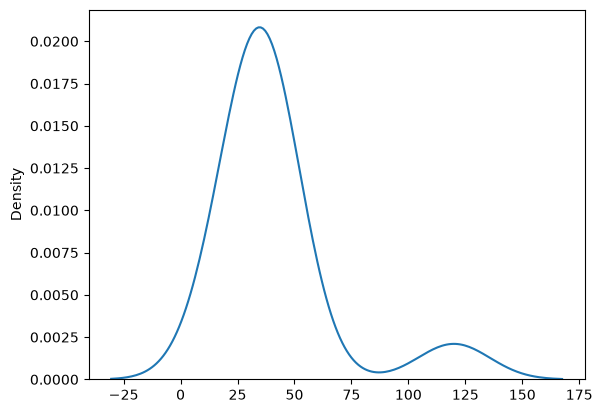

In [13]:
seaborn.kdeplot(x=edades)

<Axes: >

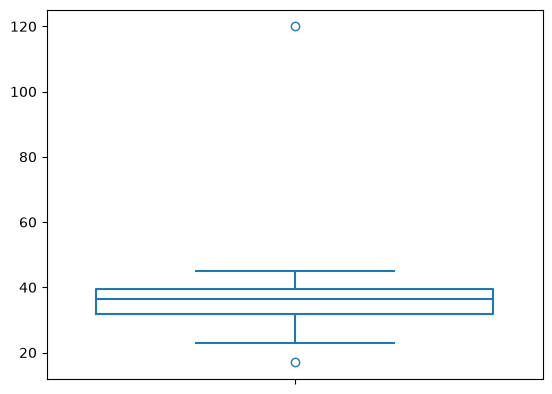

In [14]:
seaborn.boxplot(y=edades, fill=False)

<Axes: >

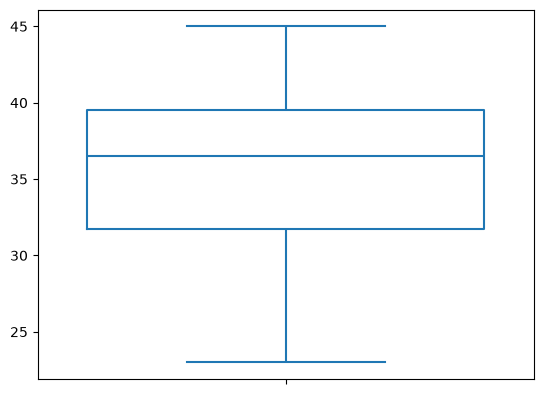

In [16]:
seaborn.boxplot(y=edades, fill=False, showfliers=False)

<Axes: ylabel='Density'>

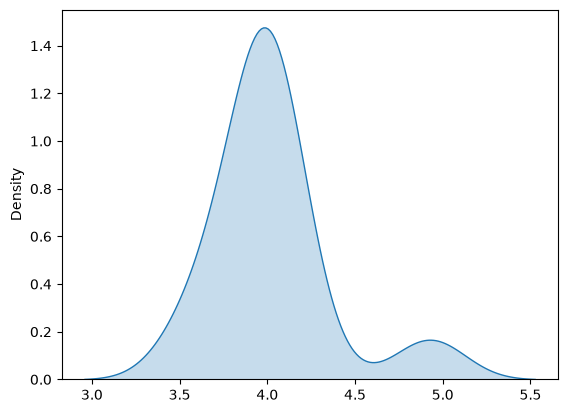

In [24]:
seaborn.kdeplot(x=numpy.log1p(edades.min() + edades), fill=True)

In [26]:
serie_edades = pandas.Series(edades)

serie_edades

0      23
1      45
2      32
3      17
4      38
5      31
6      34
7      37
8      36
9      39
10     41
11    120
dtype: int64

In [28]:
serie_edades.describe().round(1)

count     12.0
mean      41.1
std       26.0
min       17.0
25%       31.8
50%       36.5
75%       39.5
max      120.0
dtype: float64

In [29]:
serie_edades.quantile(0.25)

np.float64(31.75)

In [30]:
serie_edades

0      23
1      45
2      32
3      17
4      38
5      31
6      34
7      37
8      36
9      39
10     41
11    120
dtype: int64

In [31]:
serie_edades.sort_values()

3      17
0      23
5      31
2      32
6      34
8      36
7      37
4      38
9      39
10     41
1      45
11    120
dtype: int64

In [38]:
pandas.Series(100 * (numpy.arange(12) / 11)).round(1)

0       0.0
1       9.1
2      18.2
3      27.3
4      36.4
5      45.5
6      54.5
7      63.6
8      72.7
9      81.8
10     90.9
11    100.0
dtype: float64

In [41]:
pandas.DataFrame({
    "real": serie_edades.sort_values().values,
    "progreso": pandas.Series(100 * (numpy.arange(12) / 11)).round(1)
})

,real,progreso
0,17,0.0
1,23,9.1
2,31,18.2
3,32,27.3
4,34,36.4
5,36,45.5
6,37,54.5
7,38,63.6
8,39,72.7
9,41,81.8


In [42]:
titanic = pandas.read_csv("conjuntos/titanic.csv")

titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


<Axes: xlabel='Age', ylabel='Density'>

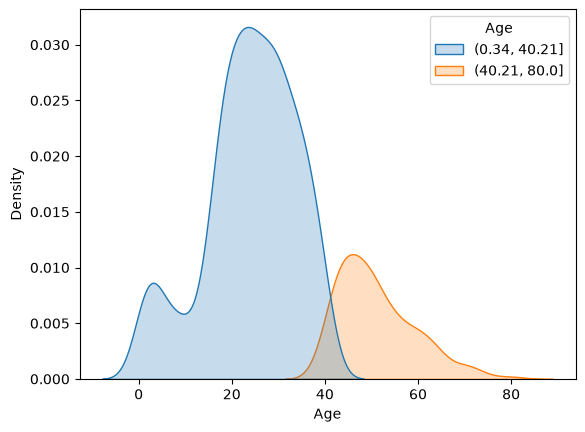

In [59]:
seaborn.kdeplot(x=titanic["Age"], fill=True, hue=pandas.cut(titanic["Age"], bins=2))

In [63]:
def grupo_edad(edad):
    if edad < 10:
        return "A1"
    elif edad < 15:
        return "A2"
    elif edad < 20:
        return "B"
    elif edad < 40:
        return "C"
    else:
        return "D"


titanic["Age"].apply(grupo_edad)

0      C
1      C
2      C
3      C
4      C
      ..
886    C
887    B
888    D
889    C
890    C
Name: Age, Length: 891, dtype: str

<Axes: xlabel='Age', ylabel='Density'>

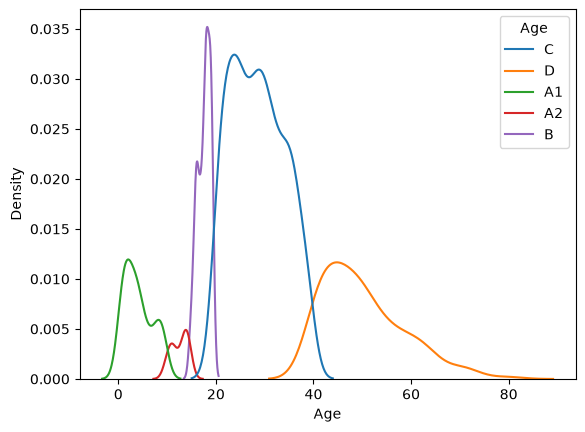

In [64]:
seaborn.kdeplot(x=titanic["Age"], hue=titanic["Age"].apply(grupo_edad))